**Computational Modelling of Social Systems - Group 34**


Research Question: Do users who positively mention each other on
X during the 2024 U.S. Presidential Election tend
to belong to the same ideological community,
and does this tendency change as election day
approaches?


Dataset: https://github.com/sinking8/x-24-us-election

In [ ]:
# Load Files
from google.colab import files

# May/July Chunk (may_july_chunk_1.csv)
# May/July Chunk (may_july_chunk_2.csv)
# May/July Chunk (may_july_chunk_3.csv)
# October Chunk (octobergap_chunk_45.csv)
# October Chunk (octobergap_chunk_46.csv)
# October Chunk (octobergap_chunk_47.csv)
uploaded = files.upload()

In [ ]:
# Imports and Installs
! pip install vaderSentiment

import pandas as pd
import re
import networkx as nx
import community.community_louvain as community_louvain
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import collections
from matplotlib import pylab as pl
import matplotlib.pyplot as plt

In [ ]:
# Load files into dataframe
df_may1 = pd.read_csv('may_july_chunk_1.csv')
df_may2 = pd.read_csv('may_july_chunk_2.csv')
df_may3 = pd.read_csv('may_july_chunk_3.csv')
df_oct1 = pd.read_csv('octobergap_chunk_45.csv')
df_oct2 = pd.read_csv('octobergap_chunk_46.csv')
df_oct3 = pd.read_csv('octobergap_chunk_47.csv')

# Combine dataframes
df_may = pd.concat([df_may1, df_may2, df_may3], ignore_index=True)
df_oct = pd.concat([df_oct1, df_oct2, df_oct3], ignore_index=True)

df_oct.head()

,type,id,username,text,url,epoch,id_str,lang,rawContent,replyCount,...,sourceUrl,sourceLabel,media,card,cashtags,viewCount,place,user,epoch_dt,date
0,tweet-,1844818977371160845,Keylo__,@MsLaFitteTweets I've always said this.... he ...,https://twitter.com/Keylo__/status/18448189773...,1728674093,1844818977371160845,en,@MsLaFitteTweets I've always said this.... he ...,0,...,PW,PW,PW,PW,PW,PW,PW,"{'id': 2666617943, 'id_str': '2666617943', 'ur...",2024-10-11 19:14:53,2024-10-11
1,tweet-,1844818976854991218,14ymedio,Gobernadores republicanos de EE UU denuncian q...,https://twitter.com/14ymedio/status/1844818976...,1728674093,1844818976854991218,es,Gobernadores republicanos de EE UU denuncian q...,0,...,PW,PW,PW,PW,PW,PW,PW,"{'id': 2295056168, 'id_str': '2295056168', 'ur...",2024-10-11 19:14:53,2024-10-11
2,tweet-,1844818974950695292,ScottTama4061,@GeneralMCNews Biden is threatening us America...,https://twitter.com/ScottTama4061/status/18448...,1728674093,1844818974950695292,en,@GeneralMCNews Biden is threatening us America...,0,...,PW,PW,PW,PW,PW,PW,PW,"{'id': 1760396282059776000, 'id_str': '1760396...",2024-10-11 19:14:53,2024-10-11
3,tweet-,1844818973184975226,ULAQMEDYA,"ABD Başkanı Joe Biden:\n\n“Milton Kasırgası, y...",https://twitter.com/ULAQMEDYA/status/184481897...,1728674092,1844818973184975226,tr,"ABD Başkanı Joe Biden:\n\n“Milton Kasırgası, y...",12,...,PW,PW,PW,PW,PW,PW,PW,"{'id': 4766947792, 'id_str': '4766947792', 'ur...",2024-10-11 19:14:52,2024-10-11
4,tweet-,1844818972899696952,SmithavenBob,@ericmmatheny Biden and Harris are threats to ...,https://twitter.com/SmithavenBob/status/184481...,1728674092,1844818972899696952,en,@ericmmatheny Biden and Harris are threats to ...,0,...,PW,PW,PW,PW,PW,PW,PW,"{'id': 1644515519599443968, 'id_str': '1644515...",2024-10-11 19:14:52,2024-10-11


In [ ]:
# Extract author
def get_author(x):
  m = re.search(r"(?:username|screen_name)['\"]:\s*['\"]([^'\"]+)", str(x)) # SOURCE: Generated with Gemini 3.5 Flash
  return m.group(1) if m else None

# Extract mentioned users
def get_mentions(x):
  return re.findall(r"screen_name['\"]:\s*['\"]([^'\"]+)", str(x)) # SOURCE: Generated with Gemini 3.5 Flash

# Author
df_may["author"] = df_may["user"].apply(get_author)
df_oct["author"] = df_oct["user"].apply(get_author)

# Mentioned users
df_may["mentions"] = df_may["mentionedUsers"].apply(get_mentions)
df_oct["mentions"] = df_oct["mentionedUsers"].apply(get_mentions)

In [ ]:
# Calculate sentiment scores
# Sentiment < -0.05 negative, > 0.05 positive, between neutral

analyzer = SentimentIntensityAnalyzer()

def get_vader_compound(text):
  compound = analyzer.polarity_scores(str(text))['compound']
  return compound

df_may['VADER_compound'] = df_may['text'].apply(get_vader_compound)
df_oct['VADER_compound'] = df_oct['text'].apply(get_vader_compound)

In [ ]:
# Keep only these columns, drop the rest
important_columns = ["author", "mentions", "text", "rawContent", "date", "epoch", "lang", "VADER_compound"]

df_may = df_may[important_columns]
df_oct = df_oct[important_columns]

In [ ]:
df_may.head(5)

,author,mentions,text,rawContent,date,epoch,lang,VADER_compound
0,B. G. Dalena,[lukepbeasley],@lukepbeasley I cant imagine anyone actually f...,@lukepbeasley I cant imagine anyone actually f...,2024-06-12,1.718237e+09,en,-0.6486
1,Brandon Holloway,[Potomacbeat],Voters can also sway me away from voting for ...,Voters can also sway me away from voting for ...,2024-06-12,1.718237e+09,en,0.1280
2,John,"[PoodleHead57, BobOnderMO]",@PoodleHead57 @BobOnderMO Can you name that am...,@PoodleHead57 @BobOnderMO Can you name that am...,2024-06-12,1.718237e+09,en,0.4349
3,Andrew Le Quesne,"[Morning_Joe, JoeNBC]",@Morning_Joe @JoeNBC The fact remains that Joe...,@Morning_Joe @JoeNBC The fact remains that Joe...,2024-06-12,1.718237e+09,en,-0.4767
4,Joe Gaeta,[],@BidenHQ That's funny you're obviously trying ...,@BidenHQ That's funny you're obviously trying ...,2024-06-12,1.718237e+09,en,0.4404


In [ ]:
# Create edge lists: extract author & mentions, convert mentions list into rows, remove empties and rename column
edges_may = df_may[["author", "mentions", "VADER_compound"]].explode("mentions").dropna().rename(columns={"mentions": "mentioned_user"})
edges_oct = df_oct[["author", "mentions", "VADER_compound"]].explode("mentions").dropna().rename(columns={"mentions": "mentioned_user"})

print(len(edges_may))
print(len(edges_oct))

# Remove rows where author mentioned themselves
edges_may = edges_may[edges_may['author'] != edges_may['mentioned_user']]
edges_oct = edges_oct[edges_oct['author'] != edges_oct['mentioned_user']]

print(len(edges_may))
print(len(edges_oct))

# Remove rows with negative sentiment because it means that they don't agree with each other (no echochamber, more conflicting parties)
edges_may = edges_may[edges_may["VADER_compound"] >= -0.05]
edges_oct = edges_oct[edges_oct["VADER_compound"] >= -0.05]

print(len(edges_may))
print(len(edges_oct))

199387
192774
199377
192729
124944
133644


In [ ]:
# Filter out top 5000 most active accounts
top_user_may = pd.concat([edges_may["author"], edges_may["mentioned_user"]]).value_counts().head(5000).index
top_user_oct = pd.concat([edges_oct["author"], edges_oct["mentioned_user"]]).value_counts().head(5000).index

# Keep only if user is as author or as mentioned_user in top 5000 (influencing user)
edges_may_filtered = edges_may[edges_may["author"].isin(top_user_may) | edges_may["mentioned_user"].isin(top_user_may)]
edges_oct_filtered = edges_oct[edges_oct["author"].isin(top_user_oct) | edges_oct["mentioned_user"].isin(top_user_oct)]

print(len(edges_may_filtered))
print(len(edges_oct_filtered))

99820
113593


In [ ]:
# Create weight column (how many times a user mentiones a other uses positively)
edges_may_counts = edges_may_filtered.groupby(['author', 'mentioned_user']).size().reset_index(name='weight')
edges_oct_counts = edges_oct_filtered.groupby(['author', 'mentioned_user']).size().reset_index(name='weight')

# Create networks for may and october
G_may = nx.from_pandas_edgelist(edges_may_counts, source='author', target='mentioned_user', edge_attr='weight', create_using=nx.DiGraph())
G_oct = nx.from_pandas_edgelist(edges_oct_counts, source='author', target='mentioned_user', edge_attr='weight', create_using=nx.DiGraph())

print(f"May Graph: {G_may.number_of_nodes()} users, {G_may.number_of_edges()} connections")
print(f"October Graph: {G_oct.number_of_nodes()} users, {G_oct.number_of_edges()} connections")

May Graph: 47791 users, 76892 connections
October Graph: 43730 users, 82272 connections


In [ ]:
# Convert to undirect graph
G_may_undirected = G_may.to_undirected()
G_oct_undirected = G_oct.to_undirected()

# Find the best fitting communities - SOURCE: https://dilipkumar.medium.com/clustering-using-louvain-algorithm-4d2b2bcfcec7
partition_may = community_louvain.best_partition(G_may_undirected)
partition_oct = community_louvain.best_partition(G_oct_undirected)

print(f"May: {partition_may}")
print(f"Amount: {len(set(partition_may.values()))}")
print(f"October: {partition_oct}")
print(f"Amount: {len(set(partition_oct.values()))}")

May: {'!': 0, 'bidenswins': 0, '! Cocaine Musk': 1, '_wake_up_USA': 1, '# MAGA': 1, 'CollinRugg': 2, 'FoxNews': 3, 'GigaBeers': 1, 'Roseblite2': 4, 'akafacehots': 5, 'asm_enterprise': 1, 'elonmuskADO': 1, 'harryjsisson': 0, 'simonateba': 3, '#1 CNN gestapo bashr': 6, 'TomFitton': 6, 'realDonaldTrump': 6, '#1 Jalen Hurts Fan 🌊🌊🌊': 7, 'AdamSchiff': 7, '#1 hater': 8, 'marionumber4': 8, '#2BIG2RIG♥️🙏🇺🇸': 0, 'SUBRATA30016572': 1, 'realXanderXjork': 0, '#AmericaFirst #VoteRhinosOut': 9, 'BradHolm': 10, 'RepJeffries': 9, 'atensnut': 11, '#BIGREDWAVE': 12, 'YouTube': 12, '#Blacklivesmatter 🌊riding with Biden🇺🇸2024': 6, 'KwikWarren': 6, '#BlueWave2024 💙🌊🏳️\\u200d🌈 🇺🇸🇺🇦': 5, 'krassenstein': 5, '#ConservTXmom': 58, 'BidensWins': 0, 'thehill': 58, '#Don': 12, '#EndFrozenPensions Canada': 14, 'Conservatives': 14, 'MelJStride': 14, 'RishiSunak': 14, '#Fool’sTalk': 15, 'BoSnerdley': 15, '#FreedomFighterReport': 16, 'Ashy_slashee': 16, '#GoCougars': 1, 'ProudElephantUS': 1, '#GoodTrouble 🚫 DMs 🇺🇦 🚫MAG

In [ ]:
# Find top 10 largest communities in May and October
may_comm = collections.Counter(partition_may.values())
oct_comm = collections.Counter(partition_oct.values())

print(f"Largest Communities in May: {may_comm.most_common(10)}")
print(f"Largest Communities in Oct: {oct_comm.most_common(10)}")

# (9, 3946) means: Unique Community ID = 9, 3946 users are in that community

# Filter down to top 10 largest communities - SOURCE: https://stackoverflow.com/questions/61659505/how-to-draw-specific-communities-from-networkx-while-ignoring-the-other-communit?utm_source=chatgpt.com
# Extract IDs of top 10
ids_may_top10 = []
for comm_id, count in may_comm.most_common(10):
  ids_may_top10.append(comm_id)

ids_oct_top10 = []
for comm_id, count in oct_comm.most_common(10):
  ids_oct_top10.append(comm_id)

# Create dictionary for top 10
partition_may_top10 = {}
for user, comm_id in partition_may.items():
  if comm_id in ids_may_top10:
    partition_may_top10[user] = comm_id

partition_oct_top10 = {}
for user, comm_id in partition_oct.items():
  if comm_id in ids_oct_top10:
    partition_oct_top10[user] = comm_id

# Only keep the top 10 largest communities, drop the rest
G_may = G_may.subgraph(partition_may_top10.keys())
G_oct = G_oct.subgraph(partition_oct_top10.keys())

# Add community attributes
nx.set_node_attributes(G_may, partition_may_top10, "community")
nx.set_node_attributes(G_oct, partition_oct_top10, "community")

Largest Communities in May: [(6, 4007), (9, 2629), (1, 2371), (0, 2345), (8, 1653), (32, 1543), (24, 1363), (7, 1007), (3, 988), (5, 958)]
Largest Communities in Oct: [(9, 5309), (1, 4343), (2, 3590), (24, 2753), (22, 2357), (26, 1761), (36, 1448), (41, 1405), (11, 1325), (21, 1285)]


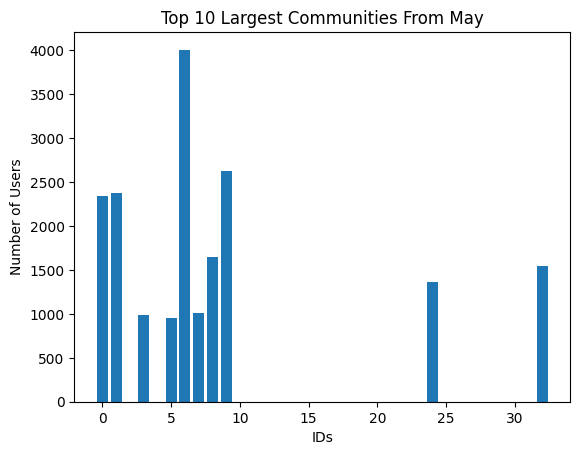

In [ ]:
ids, numbers = zip(*may_comm.most_common(10))
ids = list(ids)
numbers = list(numbers)
pl.bar(ids, numbers)
pl.title('Top 10 Largest Communities From May')
pl.xlabel('IDs')
pl.ylabel('Number of Users')
pl.show()

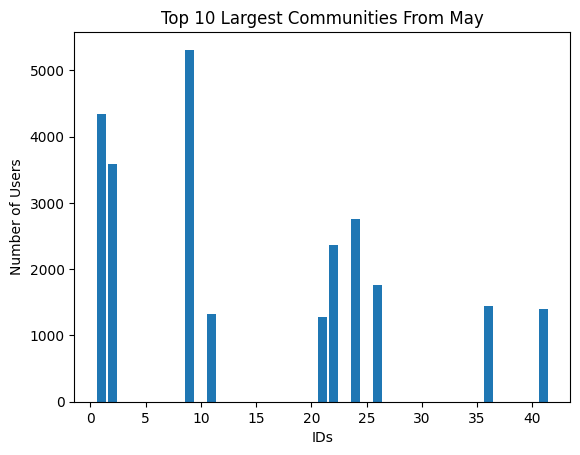

In [ ]:
ids, numbers = zip(*oct_comm.most_common(10))
ids = list(ids)
numbers = list(numbers)
pl.bar(ids, numbers)
pl.title('Top 10 Largest Communities From May')
pl.xlabel('IDs')
pl.ylabel('Number of Users')
pl.show()

In [ ]:
# Map community ids to users
df_may['community'] = df_may['author'].map(partition_may_top10)
df_oct['community'] = df_oct['author'].map(partition_oct_top10)

# Drop users who aren't in a top 10 community
df_may = df_may.dropna(subset=['community'])
df_oct = df_oct.dropna(subset=['community'])

In [ ]:
# Calculate homophily scores
homophily_may = nx.attribute_assortativity_coefficient(G_may, "community")
print(homophily_may)
homophily_oct = nx.attribute_assortativity_coefficient(G_oct, "community")
print(homophily_oct)

0.8635096867598407
0.7940286972764706


In [ ]:
# source: https://arxiv.org/abs/2411.00376 Tables 1 and 4 as well as manually added data from the iltered authors
ideology_keywords = {
    "left": ["Biden", "Joe", "JoeBiden", "TheDemocrats", "harryjsisson", "Libertarian", "Harris", "kamala", "KamalaHarris"],
    "right": ["Trump", "MAGA", "GOP", "Donald", "conservative", "realDonaldTrump", "Republican", "Melania"],
    "central": ["elonmusk", "BillClinton"]
}

ideologies_nodes = {}

left = [s.lower() for s in ideology_keywords["left"]]
right = [s.lower() for s in ideology_keywords["right"]]
central = [s.lower() for s in ideology_keywords["central"]]

authors_graph = nx.from_pandas_edgelist(edges_oct, source='author', target='mentioned_user', create_using=nx.DiGraph())

for node in authors_graph:
  node_lower = str(node).lower()
  ideology = ""
  if(node_lower in left):
    ideologies_nodes[node] = "left"
  elif(node_lower in right):
    ideologies_nodes[node] = "right"
  elif(node_lower in central):
    ideologies_nodes[node] = "central"

nx.set_node_attributes(authors_graph, ideologies_nodes, "ideologies")


homophily_total = nx.attribute_assortativity_coefficient(authors_graph, "ideologies")

print('total homophily score: ' + str(homophily_total))
print('homophily score may: ' + str(homophily_may))
print('homophily score october: ' + str(homophily_oct))

total homophily score: -0.0035763370692753283
homophily score may: 0.8635096867598407
homophily score october: 0.7940286972764706


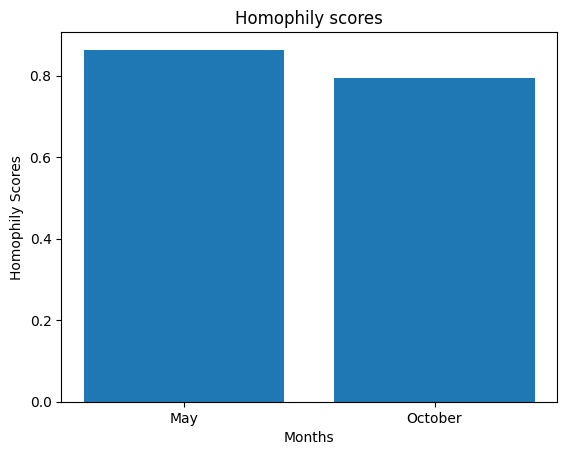

In [ ]:
months = ['May', 'October']
homophily = [homophily_may, homophily_oct]

pl.bar(months, homophily)
pl.title('Homophily scores')
pl.xlabel('Months')
pl.ylabel('Homophily Scores')
pl.show()

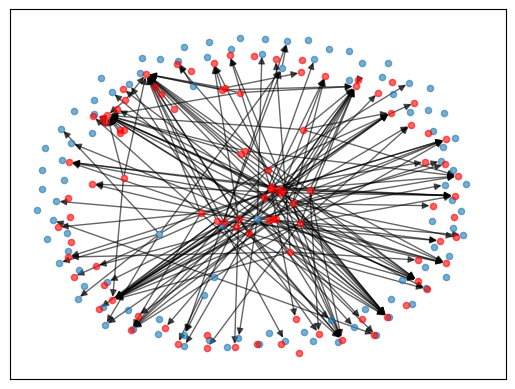

In [ ]:
# Source - https://stackoverflow.com/a/48382895
# Posted by rodgdor
# Retrieved 2026-06-06, License - CC BY-SA 3.0

G_may_sorted = sorted(G_may.degree, key=lambda x: x[1], reverse=True)[:100]
G_may_sorted_names = [x[0] for x in G_may_sorted]
splot_may = G_may.subgraph(G_may_sorted_names)

G_oct_sorted = sorted(G_oct.degree, key=lambda x: x[1], reverse=True)[:100]
G_oct_sorted_names = [x[0] for x in G_oct_sorted]
plot_oct = G_oct.subgraph(G_oct_sorted_names)

pl.figure()
nx.draw_networkx(splot_may, with_labels=False, node_size=20, alpha=0.6)
nx.draw_networkx(plot_oct, with_labels=False, node_size=20, alpha=0.6, node_color='red')

In [ ]:
# Get most influencing users of each of the top ten communities with Degree Centrality
centrality_may = nx.in_degree_centrality(G_may)
centrality_oct = nx.in_degree_centrality(G_oct)

def print_top_influencers(partition, centrality, month):
  print(f"Top 5 Most Influencers ({month})")

  communities = {}

  # Assign users to their communities
  for user, community in partition.items():
    if community not in communities:
      communities[community] = []

    communities[community].append(user)

  # Find top users of each community
  for community, users in communities.items():

    users_sorted = sorted(users,key=lambda user: centrality[user],reverse=True)

    print(f"Community {community} (Size: {len(users)} users):")

    for i, user in enumerate(users_sorted[:5], start=1):
      score = centrality[user]
      print(f"{i}. {user} (Centrality: {score:.4f})")

print_top_influencers(partition_may_top10, centrality_may, "May")
print_top_influencers(partition_oct_top10, centrality_oct, "October")

Top 5 Most Influencers (May)
Community ID 0 (Size: 2345 users):
  1. harryjsisson (Centrality: 0.0442)
  2. mmpadellan (Centrality: 0.0230)
  3. bidenswins (Centrality: 0.0110)
  4. BidensWins (Centrality: 0.0109)
  5. JoJoFromJerz (Centrality: 0.0105)
Community ID 1 (Size: 2371 users):
  1. SUBRATA30016572 (Centrality: 0.0178)
  2. _wake_up_USA (Centrality: 0.0122)
  3. RickyDoggin (Centrality: 0.0121)
  4. ProudElephantUS (Centrality: 0.0118)
  5. JDunlap1974 (Centrality: 0.0076)
Community ID 3 (Size: 988 users):
  1. simonateba (Centrality: 0.0187)
  2. FoxNews (Centrality: 0.0132)
  3. RobertKennedyJr (Centrality: 0.0039)
  4. wendyp4545 (Centrality: 0.0037)
  5. CNN (Centrality: 0.0037)
Community ID 5 (Size: 958 users):
  1. krassenstein (Centrality: 0.0138)
  2. EdKrassen (Centrality: 0.0101)
  3. akafacehots (Centrality: 0.0096)
  4. FFT1776 (Centrality: 0.0045)
  5. DefiantLs (Centrality: 0.0041)
Community ID 6 (Size: 4007 users):
  1. GOP (Centrality: 0.0800)
  2. realDonaldTr

# Manual Analysis of Political ideology of communities:

The higher the Degree Centrality, the more influencing is a X User

**Top 5 Most Influencers (May)**

Community ID 0 (Size: 2345 users): --> LEFT
  1. harryjsisson (Centrality: 0.0442)
  2. mmpadellan (Centrality: 0.0230)
  3. bidenswins (Centrality: 0.0110)
  4. BidensWins (Centrality: 0.0109)
  5. JoJoFromJerz (Centrality: 0.0105)

Community ID 1 (Size: 2371 users): --> RIGHT FOLLOWERS
  1. SUBRATA30016572 (Centrality: 0.0178)
  2. _wake_up_USA (Centrality: 0.0122)
  3. RickyDoggin (Centrality: 0.0121)
  4. ProudElephantUS (Centrality: 0.0118)
  5. JDunlap1974 (Centrality: 0.0076)

Community ID 3 (Size: 988 users): --> CENTER-RIGHT, more News
  1. simonateba (Centrality: 0.0187)
  2. FoxNews (Centrality: 0.0132)
  3. RobertKennedyJr (Centrality: 0.0039)
  4. wendyp4545 (Centrality: 0.0037)
  5. CNN (Centrality: 0.0037)

Community ID 5 (Size: 958 users): --> LEFT
  1. krassenstein (Centrality: 0.0138)
  2. EdKrassen (Centrality: 0.0101)
  3. akafacehots (Centrality: 0.0096)
  4. FFT1776 (Centrality: 0.0045)
  5. DefiantLs (Centrality: 0.0041)

Community ID 6 (Size: 4007 users): --> RIGHT
  1. GOP (Centrality: 0.0800)
  2. realDonaldTrump (Centrality: 0.0155)
  3. HouseGOP (Centrality: 0.0129)
  4. RepMTG (Centrality: 0.0102)
  5. LaraLeaTrump (Centrality: 0.0099)

Community ID 7 (Size: 1007 users): --> RIGHT
  1. DonaldJTrumpJr (Centrality: 0.0111)
  2. WhaleFUD (Centrality: 0.0043)
  3. TrumpDailyPosts (Centrality: 0.0028)
  4. MagaHAT_ETH (Centrality: 0.0027)
  5. TrumpSolMAGA (Centrality: 0.0026)

Community ID 8 (Size: 1653 users): --> LEFT
  1. ProjectLincoln (Centrality: 0.0117)
  2. RepRaskin (Centrality: 0.0074)
  3. atrupar (Centrality: 0.0066)
  4. Morning_Joe (Centrality: 0.0064)
  5. RepDanGoldman (Centrality: 0.0063)

Community ID 9 (Size: 2629 users): --> MIXED, LauraLoomer & SteveLovesAmmo are RIGHT, rest LEFT
  1. JoeBiden (Centrality: 0.0575)
  2. POTUS (Centrality: 0.0270)
  3. LauraLoomer (Centrality: 0.0145)
  4. KamalaHarris (Centrality: 0.0060)
  5. SteveLovesAmmo (Centrality: 0.0052)

Community ID 24 (Size: 1363 users): --> RIGHT LEANING, but bit sarcastic
  1. MAGA_Meme_Man (Centrality: 0.0051)
  2. _LegendaryLove (Centrality: 0.0017)
  3. StevenLegacy411 (Centrality: 0.0015)
  4. 45mx_7 (Centrality: 0.0015)
  5. cali_beachangel (Centrality: 0.0015)

Community ID 32 (Size: 1543 users): --> RIGHT (MAGA INFLUENCER)
  1. catturd2 (Centrality: 0.0130)
  2. charliekirk11 (Centrality: 0.0073)
  3. BreitbartNews (Centrality: 0.0066)
  4. bennyjohnson (Centrality: 0.0066)
  5. ScottPresler (Centrality: 0.0060)

**Top 5 Most Influencers (October)**

Community ID 1 (Size: 4343 users): --> LEFT
  1. KamalaHarris (Centrality: 0.0447)
  2. BarackObama (Centrality: 0.0166)
  3. harris_wins (Centrality: 0.0129)
  4. KamalaHQ (Centrality: 0.0126)
  5. POTUS (Centrality: 0.0118)

Community ID 2 (Size: 3590 users): --> RIGHT
  1. realDonaldTrump (Centrality: 0.0485)
  2. elonmusk (Centrality: 0.0431)
  3. JDVance (Centrality: 0.0076)
  4. TrumpWarRoom (Centrality: 0.0067)
  5. cb_doge (Centrality: 0.0057)

Community ID 36 (Size: 1448 users): --> CENTER
  1. EricLDaugh (Centrality: 0.0040)
  2. PpollingNumbers (Centrality: 0.0031)
  3. AesPolitics1 (Centrality: 0.0023)
  4. joma_gc (Centrality: 0.0019)
  5. TMZ (Centrality: 0.0018)

Community ID 9 (Size: 5309 users): --> RIGHT
  1. realTrumpNewsX (Centrality: 0.0145)
  2. GuntherEagleman (Centrality: 0.0134)
  3. MelaniaTrumpo (Centrality: 0.0124)
  4. Robert_Cr59 (Centrality: 0.0088)
  5. catturd2 (Centrality: 0.0086)

Community ID 11 (Size: 1325 users): --> LEFT, bit satricial
  1. Acyn (Centrality: 0.0099)
  2. RonFilipkowski (Centrality: 0.0091)
  3. RpsAgainstTrump (Centrality: 0.0070)
  4. atrupar (Centrality: 0.0056)
  5. MeidasTouch (Centrality: 0.0028)

Community ID 21 (Size: 1285 users): --> RIGHT
  1. LauraLoomer (Centrality: 0.0075)
  2. texan_maga (Centrality: 0.0075)
  3. ArtCandee (Centrality: 0.0031)
  4. RealAlexJones (Centrality: 0.0020)
  5. nataliegwinters (Centrality: 0.0017)

Community ID 22 (Size: 2357 users): --> RIGHT
  1. emma6USA (Centrality: 0.0034)
  2. bdonesem (Centrality: 0.0034)
  3. TrumpTrain_1 (Centrality: 0.0032)
  4. cmir_r (Centrality: 0.0029)
  5. NahBabyNah (Centrality: 0.0028)

Community ID 24 (Size: 2753 users): --> RIGHT FOLLOWERS
  1. DonnaBarford (Centrality: 0.0035)
  2. Scottie8931 (Centrality: 0.0027)
  3. MrJOHNWICK2 (Centrality: 0.0027)
  4. Hawkesbay69 (Centrality: 0.0021)
  5. GOP_is_Gutless (Centrality: 0.0020)

Community ID 26 (Size: 1761 users): --> JUST NEWS
  1. FoxNews (Centrality: 0.0071)
  2. MSNBC (Centrality: 0.0046)
  3. CBSNews (Centrality: 0.0036)
  4. CNN (Centrality: 0.0035)
  5. Morning_Joe (Centrality: 0.0032)

Community ID 41 (Size: 1405 users): --> CENTER, more into Science
  1. wman132 (Centrality: 0.0585)
  2. idrissaberkane (Centrality: 0.0004)
  3. ljmontello (Centrality: 0.0003)
  4. Fendaren (Centrality: 0.0001)
  5. JmMonteblack (Centrality: 0.0001)

In [ ]:
# Modular-Boundary E/I Index (External/Internal Ratio)

def calculate_ei_index(G, partition):
  communities = {}

  for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

  results = {}

  for comm_id, nodes in communities.items():
    nodes_set = set(nodes)

    internal = 0
    external = 0

    # Count internal and external
    for node in nodes:
      if node not in G:
        continue

      for neighbor in G.successors(node):
        if neighbor in nodes_set:
          internal += 1
        else:
          external += 1

    total = internal + external
    if total == 0:
      continue

    ei_index = (external - internal) / total
    results[comm_id] = ei_index

    print(f"Community ID {comm_id:2}: E/I Index = {ei_index:6.3f} (Internal: {internal:5}, External: {external:5})")

  return results

# Calculate E/I index for both months
print("May")
ei_may = calculate_ei_index(G_may, partition_may_top10)
print("October")
ei_oct = calculate_ei_index(G_oct, partition_oct_top10)

May
Community ID  0: E/I Index = -0.758 (Internal:  2618, External:   361)
Community ID  1: E/I Index = -0.740 (Internal:  2648, External:   396)
Community ID  3: E/I Index = -0.699 (Internal:  1128, External:   200)
Community ID  5: E/I Index = -0.729 (Internal:  1072, External:   168)
Community ID  6: E/I Index = -0.771 (Internal:  5907, External:   764)
Community ID  7: E/I Index = -0.792 (Internal:  1508, External:   175)
Community ID  8: E/I Index = -0.685 (Internal:  2161, External:   404)
Community ID  9: E/I Index = -0.718 (Internal:  3302, External:   541)
Community ID 24: E/I Index = -0.926 (Internal:  3336, External:   129)
Community ID 32: E/I Index = -0.708 (Internal:  1770, External:   303)
October
Community ID  1: E/I Index = -0.648 (Internal:  5785, External:  1237)
Community ID  2: E/I Index = -0.652 (Internal:  4731, External:   998)
Community ID 36: E/I Index = -0.605 (Internal:  1685, External:   415)
Community ID  9: E/I Index = -0.633 (Internal:  7121, External:  

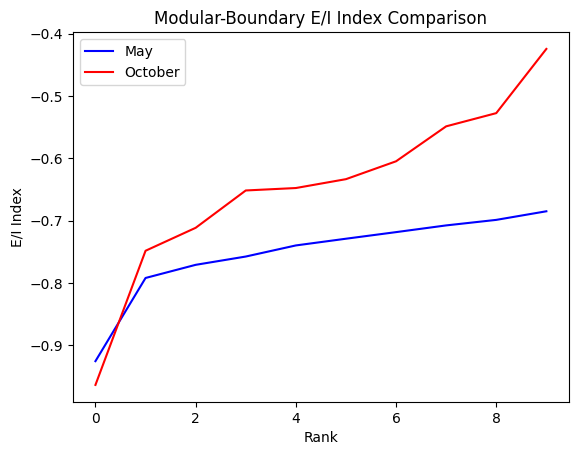

In [ ]:
# Sort values from lowest (strongest echo chamber) to highest
may_values = sorted(ei_may.values())
oct_values = sorted(ei_oct.values())

plt.plot(may_values, color='blue', label='May')
plt.plot(oct_values, color='red', label='October')

plt.title('Modular-Boundary E/I Index Comparison')
plt.xlabel('Rank')
plt.ylabel('E/I Index')
plt.legend()

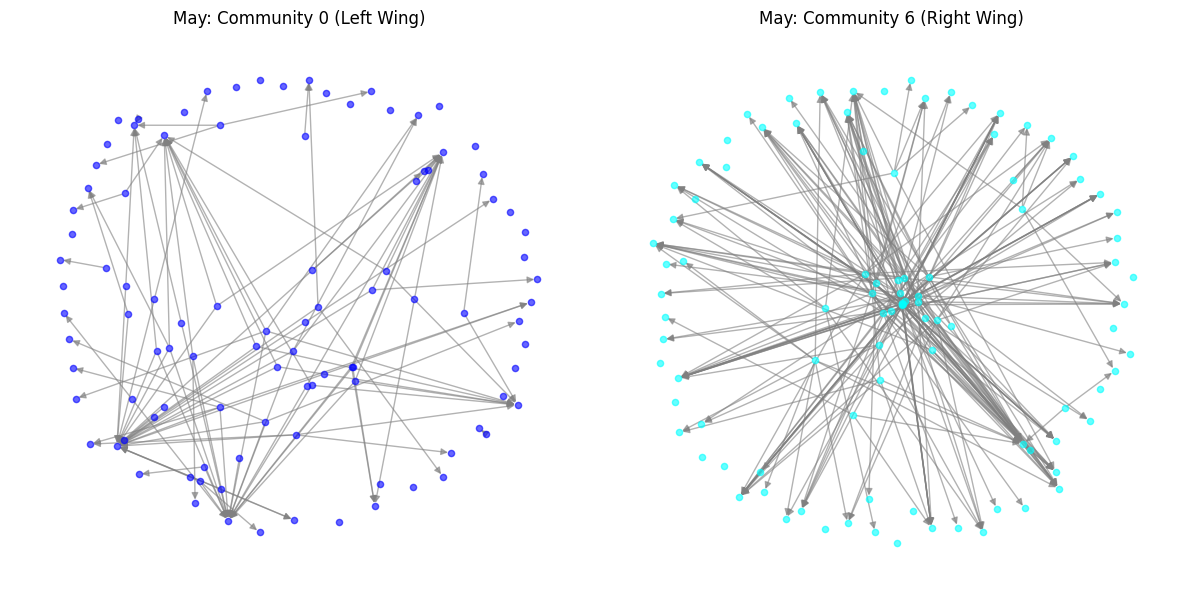

In [ ]:
# Comparision of a right-wing to a left-wing network for May and October (only top 100 users)

# May (Community 0 vs Community 6)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nodes_may_0 = [n for n, c in partition_may_top10.items() if c == 0]
top_100_may_0 = sorted(nodes_may_0, key=lambda n: G_may.degree(n), reverse=True)[:100]
sub_may_0 = G_may.subgraph(top_100_may_0)
nx.draw(sub_may_0, node_size=20, node_color='blue', alpha=0.6, edge_color='gray')
plt.title("May: Community 0 (Left Wing)")

plt.subplot(1, 2, 2)
nodes_may_6 = [n for n, c in partition_may_top10.items() if c == 6]
top_100_may_6 = sorted(nodes_may_6, key=lambda n: G_may.degree(n), reverse=True)[:100]
sub_may_6 = G_may.subgraph(top_100_may_6)
nx.draw(sub_may_6, node_size=20, node_color='cyan', alpha=0.6, edge_color='gray')
plt.title("May: Community 6 (Right Wing)")

plt.tight_layout()
plt.show()

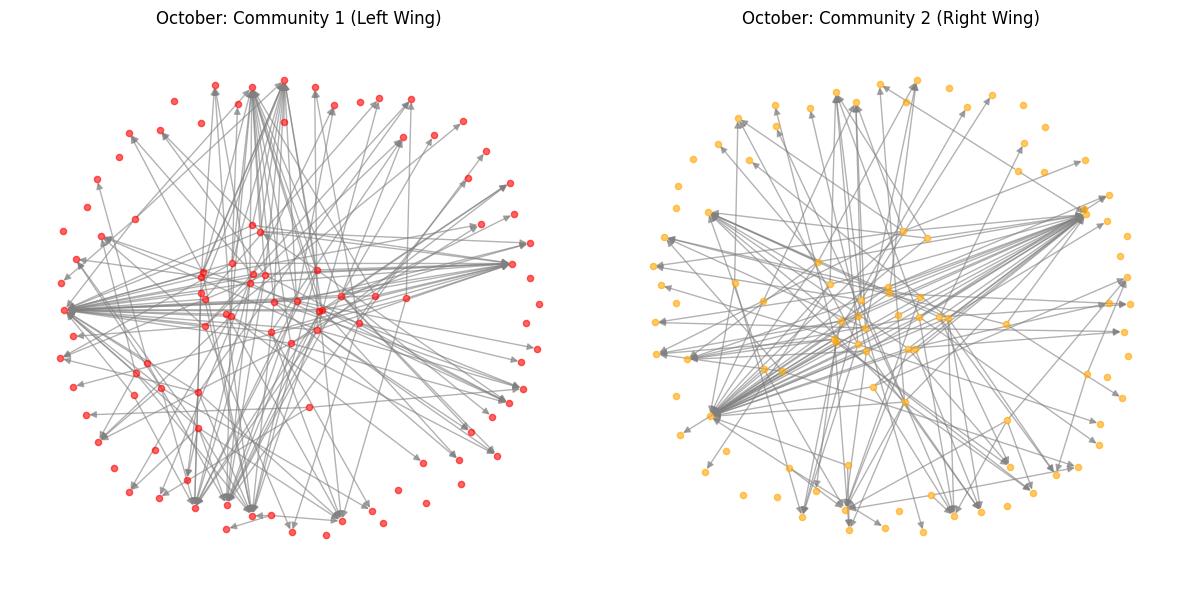

In [ ]:
# October (Community 1 vs Community 2)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nodes_oct_1 = [n for n, c in partition_oct_top10.items() if c == 1]
top_100_oct_1 = sorted(nodes_oct_1, key=lambda n: G_oct.degree(n), reverse=True)[:100]
sub_oct_1 = G_oct.subgraph(top_100_oct_1)
nx.draw(sub_oct_1, node_size=20, node_color='red', alpha=0.6, edge_color='gray')
plt.title("October: Community 1 (Left Wing)")

plt.subplot(1, 2, 2)
nodes_oct_2 = [n for n, c in partition_oct_top10.items() if c == 2]
top_100_oct_2 = sorted(nodes_oct_2, key=lambda n: G_oct.degree(n), reverse=True)[:100]
sub_oct_2 = G_oct.subgraph(top_100_oct_2)
nx.draw(sub_oct_2, node_size=20, node_color='orange', alpha=0.6, edge_color='gray')
plt.title("October: Community 2 (Right Wing)")

plt.tight_layout()
plt.show()